# LLM-as-a-Judge Evaluation of Coaching Feedback

## Introduction

This notebook evaluates the quality of the coaching feedback generated in **1_feedback_coach.ipynb**.

Instead of relying on human annotators, we adopt an LLM-as-a-Judge protocol using two independent state-of-the-art models:

* GPT-4.1
* GPT-4o

Using two judges allows us to estimate evaluation robustness and quantify inter-judge agreement.

---

## Evaluation Dimensions

Each response is evaluated on four dimensions using a 1–5 Likert scale.
- **Contextual Grounding:** Measures whether the generated feedback is supported by the emotion timeline.

- **Actionability:** Measures the practical usefulness of the recommendations.

- **Persona Consistency:** Measures adherence to the assigned coaching persona.

- **Clarity:** Measures readability and communication effectiveness.

---

## Evaluation Protocol

Each judge receives:

1. Emotion timeline
2. Generated feedback
3. Evaluation rubric

and returns scores for:

```text
Contextual Grounding
Actionability
Persona Consistency
Clarity
```

---

## Judge Agreement Analysis

To assess evaluation reliability we compare GPT-4.1 and GPT-4o scores using:

* Pearson Correlation
* Scatter plots
* Distribution plots

Moderate-to-high correlations indicate that both judges are capturing similar quality signals.

---

## Output

This notebook exports:

```text
llm_evaluations_gemma4.xlsx
```

containing:

* response metadata
* GPT-4.1 scores
* GPT-4o scores
* aggregated scores

These scores are used for statistical analysis in **3_mixed_effects_model.ipynb**.

In [ ]:
# removed presentation_type for blind test (persona consistency)
# added "explanation" output
JUDGE_SYSTEM_PROMPT = """
You are an expert evaluator of presentation coaching feedback.

Your task is to rate the quality of AI-generated feedback based on a structured rubric.

You MUST:
- evaluate only what is written
- ignore style preferences
- use the provided scale consistently
- output ONLY valid JSON
"""

JUDGE_PROMPT_TEMPLATE = """
###Instruction###

You are an expert evaluator of AI-generated presentation coaching feedback.

Your task is to evaluate the quality of feedback generated for presentation improvement using a structured scoring rubric with an explanation. The explanation must be concise (1–3 sentences).

You MUST:
- evaluate only the provided feedback
- base your evaluation exclusively on the provided emotion timeline
- apply the scoring rubric consistently across all evaluations
- avoid assumptions not supported by the input
- produce strict and calibrated scores

Scoring guidelines:
- A score of 5.0 should only be assigned when the criterion is strongly and consistently satisfied.
- A score of 1.0 should indicate severe deficiencies.
- Use the full rating scale (continuous).

###Rubric (1–5 scale)###

1. Contextual grounding:
How well does the feedback align with the emotion timeline?

2. Actionability:
How actionable and specific are the recommendations?

3. Persona consistency:
How consistent is the feedback with the assigned persona (Academic / Pitch)?

4. Clarity:
How clear and structured is the feedback?

###Input###

Emotion timeline:
{emotion_timeline}

AI feedback:
{model_output}

Persona:
{persona}

###Output format###

Return ONLY valid JSON:

  "grounding": float,
  "actionability": float,
  "persona_consistency": float,
  "clarity": float,
  "explanation": str

"""

In [2]:
PAIRWISE_JUDGE_SYSTEM = """
You are an expert evaluator of AI-generated presentation coaching feedback.

Your task is to compare two feedback responses and determine which one better helps the presenter improve their presentation.

You MUST:
- evaluate only the provided responses
- ignore formatting differences unless they affect clarity
- focus on emotional grounding, actionability, clarity, and coaching usefulness
- avoid positional bias
- output ONLY valid JSON
"""

PAIRWISE_JUDGE_PROMPT = """
###Instruction###

Compare two AI-generated feedback responses for the same presentation.

###Evaluation criteria###

1. Which response better reflects the emotional dynamics?
2. Which response provides more actionable recommendations?
3. Which response is clearer and easier to follow?
4. Which response would better help the presenter improve?

###Input###

Emotion timeline:
{emotion_timeline}

Response A:
{response_a}

Response B:
{response_b}

###Output format###

Return ONLY JSON:

  "better_grounding": "A" | "B" | "Tie",
  "better_actionability": "A" | "B" | "Tie",
  "better_clarity": "A" | "B" | "Tie",
  "better_overall": "A" | "B" | "Tie",
  "explanation": str
  
"""

## Experimental Setup

In [ ]:
import os
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")


In [ ]:
import re
import json
import numpy as np
import pandas as pd
from litellm import completion

#JUDGE_MODEL = "gpt-4o" 
#JUDGE_MODEL = "gpt-4.1"
#JUDGE_MODEL = "gemini/gemini-live-2.5-flash-native-audio"
JUDGE_MODEL = "ollama_chat/qwen3.5:latest"

API_BASE = "https://claribel-isotypic-gertrude.ngrok-free.dev"


CONDITIONS = [
    "academic_simple",
    "academic_detailed",
    "pitch_simple",
    "pitch_detailed"
]

SCALAR_METRICS = [
    "grounding",
    "actionability",
    "persona_consistency",
    "clarity"
]

PAIRWISE_CONDITIONS = [
    ("academic_simple", "academic_detailed"),
    ("pitch_simple", "pitch_detailed"),
    ("academic_simple", "pitch_simple"),
    ("academic_detailed", "pitch_detailed")
]

def extract_json(text):
    # Remove markdown code blocks if they exist (```json or ```)
    text = re.sub(r"```json|```", "", text)
    return text.strip()


def run_scalar_judge(model, emotion_timeline, output, persona):
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        emotion_timeline=emotion_timeline,
        model_output=output,
        persona=persona
    )
    #print(prompt)

    res = completion(
        model=model,
        api_base=API_BASE,
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ],
        temperature=0.0
    )
    
    raw_content = res.choices[0].message.content
    cleaned_content = extract_json(raw_content)

    try:
        return json.loads(cleaned_content)
    except json.JSONDecodeError:
        # Fallback logic if the model still fails to output valid JSON
        print(f"Failed to parse JSON. Raw output: {raw_content}")
        return {
            "grounding": 0.0, 
            "actionability": 0.0, 
            "persona_consistency": 0.0, 
            "clarity": 0.0, 
            "explanation": "Parsing Error"
        }


def run_pairwise(model, emotion_timeline, a, b):
    prompt = PAIRWISE_JUDGE_PROMPT.format(
        emotion_timeline=emotion_timeline,
        response_a=a,
        response_b=b
    )
    #print(prompt)

    res = completion(
        model=model,
        api_base=API_BASE,
        messages=[
            {"role": "system", "content": PAIRWISE_JUDGE_SYSTEM},
            {"role": "user", "content": prompt}
        ],
        temperature=0.0
    )
    
    raw_content = res.choices[0].message.content
    cleaned_content = extract_json(raw_content)

    try:
        return json.loads(cleaned_content)
    except json.JSONDecodeError:
        # Fallback logic if the model still fails to output valid JSON
        print(f"Failed to parse JSON. Raw output: {raw_content}")
        return {
            "better_grounding": "", 
            "better_actionability": "", 
            "better_clarity": "", 
            "better_overall": "", 
            "explanation": "Parsing Error"
        }

def evaluate_row(row):
    outputs = {
        "academic_simple": row["academic_simple"],
        "academic_detailed": row["academic_detailed"],
        "pitch_simple": row["pitch_simple"],
        "pitch_detailed": row["pitch_detailed"]
    }

    scalar_results = {}
    pairwise_results = []

    # scalar evaluation
    for cond, text in outputs.items():
        persona_type = "Academic" if "academic" in cond else "Pitch" 

        scalar_results[cond] = run_scalar_judge(
            JUDGE_MODEL,
            row["emotion_timeline"],
            text,
            persona_type
        )

    # pairwise comparisons
    for a, b in PAIRWISE_CONDITIONS:
        pairwise_results.append(
            run_pairwise(
                JUDGE_MODEL,
                row["emotion_timeline"],
                outputs[a],
                outputs[b]
            )
        )

    return {
        "scalar": scalar_results,
        "pairwise": pairwise_results
    }



In [10]:
from tqdm import tqdm 
import pandas as pd
import json

def append_jsonl(path, record):
    with open(path, "a") as f:
        f.write(json.dumps(record) + "\n")

def run_experiment(input_file, output_file):
    df = pd.read_excel(input_file)

    for idx, row in tqdm(df.iterrows(), total=len(df)):

        try:
            result = evaluate_row(row)

            record = {
                "index": idx,
                "event": row["event"],
                "title": row["title"],
                "category": row["category"],
                "scalar": result["scalar"],
                "pairwise": result["pairwise"]
            }

            append_jsonl(output_file, record)


        except Exception as e:
            print(f"Error at row {idx}: {e}")
            continue

In [ ]:
input_file = "llm_evaluations_gemma4.xlsx"
output_file = "llm_judges_results_checkpoint_qwen35.jsonl"

run_experiment(input_file, output_file)

In [19]:
import pandas as pd
import json
import re


def process_results(file_path):
    all_rows = []
    pairwise_rows = []

    comparison_labels = [
        ("academic_simple", "academic_detailed"), # Index 0
        ("pitch_simple", "pitch_detailed"),       # Index 1
        ("academic_simple", "pitch_simple"),       # Index 2
        ("academic_detailed", "pitch_detailed")    # Index 3
    ]
    
    with open(file_path, "r") as f:
        for line in f:
            record = json.loads(line)

            print(record)
            # Record contains: index, event, title, category, scalar, pairwise
            # Each 'scalar' entry has 4 conditions: academic_simple, academic_detailed, etc.
            for cond_name, metrics in record["scalar"].items():
        
                if metrics:
                    # Split condition name (e.g., 'academic_simple') into persona and complexity
                    persona, complexity = cond_name.split("_")
                    
                    all_rows.append({
                        'presentation_id': record["index"], # Using index as ID
                        'type': record["category"],        # Your original presentation type
                        'persona': persona,
                        'complexity': complexity,
                        'grounding': metrics.get('grounding'),
                        'actionability': metrics.get('actionability'),
                        'persona_consistency': metrics.get('persona_consistency'),
                        'clarity': metrics.get('clarity')
                    })

            for i, res in enumerate(record["pairwise"]):
                if res and i < len(comparison_labels):
                    cond_a, cond_b = comparison_labels[i]
                    pairwise_rows.append({
                        'presentation_id': record["index"],
                        'presentation_type': record["category"],
                        'comparison': f"{cond_a}_vs_{cond_b}",
                        'model_a': cond_a,
                        'model_b': cond_b,
                        'better_grounding': res.get('better_grounding'),
                        'better_actionability': res.get('better_actionability'),
                        'better_clarity': res.get('better_clarity'),
                        'better_overall': res.get('better_overall'),
                        'explanation': res.get('explanation')
                    })
    
    return pd.DataFrame(all_rows), pd.DataFrame(pairwise_rows)

# load and transform
df_scale, df_pair = process_results("llm_evaluation_results_checkpoint_gpt4o.jsonl")

df_scale, df_pair



{'index': 0, 'event': '3MT', 'title': '3MT_2024_0', 'category': 'academic', 'scalar': {'academic_simple': {'grounding': 4.0, 'actionability': 4.5, 'persona_consistency': 4.5, 'clarity': 4.5, 'explanation': 'The feedback aligns well with the emotion timeline, particularly in identifying areas for emotional consistency. Recommendations are specific and actionable, focusing on emotional control and transition refinement. The feedback is consistent with the academic persona, emphasizing scientific rigor and clarity. Overall, the feedback is clear and well-structured, though slightly more emphasis on grounding could enhance alignment with the timeline.'}, 'academic_detailed': {'grounding': 4.0, 'actionability': 4.5, 'persona_consistency': 5.0, 'clarity': 4.5, 'explanation': 'The feedback aligns well with the emotion timeline, particularly in identifying emotional disconnects and transitions. Recommendations are specific and actionable, offering clear steps for improvement. The feedback is c

(    presentation_id      type   persona complexity  grounding  actionability  \
 0                 0  academic  academic     simple        4.0            4.5   
 1                 0  academic  academic   detailed        4.0            4.5   
 2                 0  academic     pitch     simple        4.0            4.5   
 3                 0  academic     pitch   detailed        4.5            4.0   
 4                 1  academic  academic     simple        4.5            4.0   
 ..              ...       ...       ...        ...        ...            ...   
 95               26     pitch     pitch   detailed        4.0            4.5   
 96               27     pitch  academic     simple        4.0            4.5   
 97               27     pitch  academic   detailed        4.5            4.0   
 98               27     pitch     pitch     simple        4.5            4.8   
 99               27     pitch     pitch   detailed        4.5            4.8   
 
     persona_consistency  

In [20]:
df_scale.iloc[60:80]

,presentation_id,type,persona,complexity,grounding,actionability,persona_consistency,clarity
60,15,academic,academic,simple,3.5,4.0,4.5,4.5
61,15,academic,academic,detailed,4.0,4.5,3.5,4.0
62,15,academic,pitch,simple,4.0,4.5,5.0,4.5
63,15,academic,pitch,detailed,4.0,4.5,5.0,4.5
64,16,academic,academic,simple,3.5,4.0,5.0,4.5
65,16,academic,academic,detailed,4.0,4.5,5.0,4.5
66,16,academic,pitch,simple,3.0,4.5,5.0,4.5
67,16,academic,pitch,detailed,4.0,4.5,5.0,4.5
68,19,academic,academic,simple,4.0,4.5,5.0,4.5
69,19,academic,academic,detailed,4.0,4.5,5.0,4.5


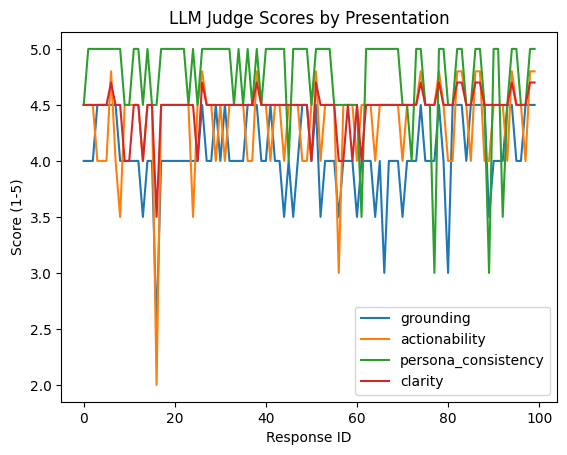

In [21]:
import matplotlib.pyplot as plt

df_scale['grounding'].plot()
df_scale['actionability'].plot()
df_scale['persona_consistency'].plot()
df_scale['clarity'].plot()
plt.legend()
plt.title("LLM Judge Scores by Presentation")
plt.xlabel("Response ID")
plt.ylabel("Score (1-5)")
plt.show()


In [26]:
# plot pairwise comparison results
comparison_counts = df_pair.groupby('comparison').agg({
    'better_grounding': lambda x: (x == 'A').sum(),
    'better_actionability': lambda x: (x == 'A').sum(),
    'better_clarity': lambda x: (x == 'A').sum(),
    'better_overall': lambda x: (x == 'A').sum()
}).reset_index()

comparison_counts


,comparison,better_grounding,better_actionability,better_clarity,better_overall
0,academic_detailed_vs_pitch_detailed,13,5,13,11
1,academic_simple_vs_academic_detailed,18,16,10,17
2,academic_simple_vs_pitch_simple,3,0,3,2
3,pitch_simple_vs_pitch_detailed,25,24,20,24


In [ ]:
# numeric types
numeric_cols = ['grounding', 'actionability', 'persona_consistency', 'clarity']
df_real[numeric_cols] = df_real[numeric_cols].apply(pd.to_numeric, errors='coerce')

### Dummy dataset

In [4]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Configuration
num_ids = 21
variations_per_id = 4  # Number of rows per presentation_id

# Categorical options
types = ['academic', 'pitch']
personas = ['academic', 'pitch']
complexities = ['simple', 'detailed']

data = []

# Generate data
for i in range(1, num_ids + 1):
    pid = f"{i:03d}"
    for _ in range(variations_per_id):
        data.append({
            'presentation_id': pid,
            'type': np.random.choice(types),
            'persona': np.random.choice(personas),
            'complexity': np.random.choice(complexities),
            'grounding': round(np.random.uniform(3.0, 5.0), 1),
            'actionability': round(np.random.uniform(3.0, 5.0), 1),
            'persona_consistency': round(np.random.uniform(3.0, 5.0), 1),
            'toxicity': round(np.random.uniform(0.0, 0.3), 1)
        })

# Create DataFrame
df = pd.DataFrame(data)

# Display the first few rows
df.head()

,presentation_id,type,persona,complexity,grounding,actionability,persona_consistency,toxicity
0,001,academic,pitch,simple,3.4,4.6,4.2,0.1
1,001,academic,academic,simple,4.7,4.2,4.4,0.0
2,001,pitch,pitch,detailed,4.9,3.0,5.0,0.2
3,001,pitch,pitch,simple,3.9,3.6,4.2,0.0
4,002,pitch,pitch,detailed,3.5,3.2,4.2,0.1


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   presentation_id      84 non-null     str    
 1   type                 84 non-null     str    
 2   persona              84 non-null     str    
 3   complexity           84 non-null     str    
 4   grounding            84 non-null     float64
 5   actionability        84 non-null     float64
 6   persona_consistency  84 non-null     float64
 7   toxicity             84 non-null     float64
dtypes: float64(4), str(4)
memory usage: 5.4 KB


In [26]:
# Ensure categorical variables
df["persona"] = df["persona"].astype("category")
df["complexity"] = df["complexity"].astype("category")
df["type"] = df["type"].astype("category")
df["presentation_id"] = df["presentation_id"].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   presentation_id      84 non-null     category
 1   type                 84 non-null     category
 2   persona              84 non-null     category
 3   complexity           84 non-null     category
 4   grounding            84 non-null     float64 
 5   actionability        84 non-null     float64 
 6   persona_consistency  84 non-null     float64 
 7   toxicity             84 non-null     float64 
 8   presentation_type    84 non-null     category
dtypes: category(5), float64(4)
memory usage: 3.4 KB
